In [3]:
import pandas as pd
import numpy as np
import pyarrow
from datetime import datetime
import glob
import matplotlib.pyplot as plt
import os

# Zadanie 1

In [4]:
files = glob.glob("data/*.parquet")

print("Liczba plików:", len(files))
print(files)

Liczba plików: 8
['data\\0000.parquet', 'data\\0001.parquet', 'data\\0002.parquet', 'data\\0003.parquet', 'data\\0004.parquet', 'data\\0005.parquet', 'data\\0006.parquet', 'data\\0007.parquet']


### Wczytanie danych

In [5]:
dataframes=[]
for file in files:
    temp_df=pd.read_parquet(file)
    dataframes.append(temp_df)

df_original=pd.concat(dataframes,ignore_index=True)

### Informacje o danych

In [6]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9178864 entries, 0 to 9178863
Data columns (total 17 columns):
 #   Column               Dtype
---  ------               -----
 0   sid                  int64
 1   sid_profile          int64
 2   post_id              str  
 3   profile_id           int64
 4   date                 str  
 5   post_type            int64
 6   description          str  
 7   likes                int64
 8   comments             int64
 9   username             str  
 10  bio                  str  
 11  following            int64
 12  followers            int64
 13  num_posts            int64
 14  is_business_account  bool 
 15  lang                 str  
 16  category             str  
dtypes: bool(1), int64(9), str(7)
memory usage: 3.8 GB


### Ilość pamięci zajmowana przez ramkę 

In [7]:
df_original.memory_usage()

Index                         132
sid                      73430912
sid_profile              73430912
post_id                 174279895
profile_id               73430912
date                    247829328
post_type                73430912
description            1683968146
likes                    73430912
comments                 73430912
username                190322074
bio                     842725069
following                73430912
followers                73430912
num_posts                73430912
is_business_account       9178864
lang                     91788640
category                228648438
dtype: int64

### Całkowite zużycie RAM

In [8]:
sum(df_original.memory_usage())

4129618794

In [9]:
def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

sizeof_fmt(sum(df_original.memory_usage(deep=True)))

'3.8GiB'

# Zadanie 2

### Kopia danych do optymalizacji

In [10]:
df_optimized=df_original.copy()
df_optimized.describe()

,sid,sid_profile,profile_id,post_type,likes,comments,following,followers,num_posts
count,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06,9.178864e+06
mean,2.374612e+07,2.836848e+06,2.569090e+09,1.010795e+00,3.375654e+02,7.630528e+00,1.285882e+03,1.572609e+04,7.847129e+02
std,1.542252e+07,1.443643e+06,7.866468e+10,1.033726e-01,8.149282e+03,1.480018e+02,2.606544e+03,5.964296e+05,1.836388e+03
min,6.025000e+03,-1.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.763476e+06,1.002857e+06,2.079768e+08,1.000000e+00,2.000000e+01,0.000000e+00,3.500000e+02,3.010000e+02,9.600000e+01
50%,2.302429e+07,3.541741e+06,1.162968e+09,1.000000e+00,4.600000e+01,2.000000e+00,7.460000e+02,7.230000e+02,2.990000e+02
75%,3.943089e+07,3.989080e+06,3.998020e+09,1.000000e+00,1.140000e+02,5.000000e+00,1.454000e+03,1.647000e+03,8.150000e+02
max,4.333055e+07,4.510785e+06,9.001013e+13,3.000000e+00,8.822952e+06,1.739880e+05,1.710028e+06,2.854576e+08,1.837300e+05


In [11]:
pd.options.display.float_format = '{:.5f}'.format
df_optimized.describe()

,sid,sid_profile,profile_id,post_type,likes,comments,following,followers,num_posts
count,9178864.00000,9178864.00000,9178864.00000,9178864.00000,9178864.00000,9178864.00000,9178864.00000,9178864.00000,9178864.00000
mean,23746123.20009,2836848.38553,2569089966.28538,1.01080,337.56536,7.63053,1285.88175,15726.08580,784.71288
std,15422515.10602,1443642.55933,78664679061.18510,0.10337,8149.28198,148.00184,2606.54416,596429.55955,1836.38806
min,6025.00000,-1.00000,4.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,5763475.75000,1002857.00000,207976813.00000,1.00000,20.00000,0.00000,350.00000,301.00000,96.00000
50%,23024292.50000,3541741.00000,1162967787.00000,1.00000,46.00000,2.00000,746.00000,723.00000,299.00000
75%,39430894.25000,3989080.00000,3998020150.00000,1.00000,114.00000,5.00000,1454.00000,1647.00000,815.00000
max,43330548.00000,4510785.00000,90010129721363.00000,3.00000,8822952.00000,173988.00000,1710028.00000,285457645.00000,183730.00000


In [12]:
for column in df_optimized.columns:
    print(f'{column}: {sizeof_fmt(df_optimized[column].memory_usage(deep=True))}')

sid: 70.0MiB
sid_profile: 70.0MiB
post_id: 166.2MiB
profile_id: 70.0MiB
date: 236.3MiB
post_type: 70.0MiB
description: 1.6GiB
likes: 70.0MiB
comments: 70.0MiB
username: 181.5MiB
bio: 803.7MiB
following: 70.0MiB
followers: 70.0MiB
num_posts: 70.0MiB
is_business_account: 8.8MiB
lang: 87.5MiB
category: 218.1MiB


### Optymalizacja wartości tekstowych

In [13]:
sizeof_fmt(df_optimized["post_id"].memory_usage(deep=True))

'166.2MiB'

In [14]:
sizeof_fmt(df_optimized['post_id'].astype('category').memory_usage(deep=True))

'202.3MiB'

In [15]:
sizeof_fmt(df_optimized["date"].memory_usage(deep=True))

'236.3MiB'

In [16]:
sizeof_fmt(pd.to_datetime(df_optimized['date']).memory_usage(deep=True))

'70.0MiB'

In [17]:
sizeof_fmt(df_optimized["description"].memory_usage(deep=True))

'1.6GiB'

In [18]:
sizeof_fmt(df_optimized['description'].astype('category').memory_usage(deep=True))

'1.5GiB'

In [19]:
sizeof_fmt(df_optimized["username"].memory_usage(deep=True))

'181.5MiB'

In [20]:
sizeof_fmt(df_optimized['username'].astype('category').memory_usage(deep=True))

'52.4MiB'

In [21]:
sizeof_fmt(df_optimized["bio"].memory_usage(deep=True))

'803.7MiB'

In [22]:
sizeof_fmt(df_optimized['bio'].astype('category').memory_usage(deep=True))

'106.8MiB'

In [23]:
sizeof_fmt(df_optimized["lang"].memory_usage(deep=True))

'87.5MiB'

In [24]:
sizeof_fmt(df_optimized['lang'].astype('category').memory_usage(deep=True))

'8.8MiB'

In [25]:
sizeof_fmt(df_optimized["category"].memory_usage(deep=True))

'218.1MiB'

In [26]:
sizeof_fmt(df_optimized['category'].astype('category').memory_usage(deep=True))

'8.8MiB'

In [27]:
df_optimized["lang"] = df_optimized["lang"].astype("category")
df_optimized["bio"] = df_optimized["bio"].astype("category")
df_optimized["username"] = df_optimized["username"].astype("category")
df_optimized["description"] = df_optimized["description"].astype("category")
df_optimized["date"] = df_optimized["date"].astype("category")
df_optimized["category"] = df_optimized["category"].astype("category")

In [28]:
sizeof_fmt(df_original.memory_usage(deep=True).sum())

'3.8GiB'

In [29]:
sizeof_fmt(df_optimized.memory_usage(deep=True).sum())

'2.7GiB'

In [30]:
df_optimized.info()

<class 'pandas.DataFrame'>
RangeIndex: 9178864 entries, 0 to 9178863
Data columns (total 17 columns):
 #   Column               Dtype   
---  ------               -----   
 0   sid                  int64   
 1   sid_profile          int64   
 2   post_id              str     
 3   profile_id           int64   
 4   date                 category
 5   post_type            int64   
 6   description          category
 7   likes                int64   
 8   comments             int64   
 9   username             category
 10  bio                  category
 11  following            int64   
 12  followers            int64   
 13  num_posts            int64   
 14  is_business_account  bool    
 15  lang                 category
 16  category             category
dtypes: bool(1), category(6), int64(9), str(1)
memory usage: 2.7 GB


### Optymalizacja wartości liczbowych

In [31]:
for column in df_optimized.select_dtypes(include="int64").columns:
    print(
        column,
        "min:", df_optimized[column].min(),
        "max:", df_optimized[column].max()
    )

sid min: 6025 max: 43330548
sid_profile min: -1 max: 4510785
profile_id min: 4 max: 90010129721363
post_type min: 1 max: 3
likes min: 0 max: 8822952
comments min: 0 max: 173988
following min: 0 max: 1710028
followers min: 0 max: 285457645
num_posts min: 0 max: 183730


In [32]:
sizeof_fmt(df_optimized["post_type"].memory_usage(deep=True))

'70.0MiB'

In [33]:
sizeof_fmt(pd.to_numeric(df_optimized["post_type"],downcast="unsigned").memory_usage(deep=True))

'8.8MiB'

In [34]:
sizeof_fmt(df_optimized["sid"].memory_usage(deep=True))

'70.0MiB'

In [35]:
sizeof_fmt(pd.to_numeric(df_optimized["sid"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [36]:
sizeof_fmt(df_optimized["sid_profile"].memory_usage(deep=True))

'70.0MiB'

In [37]:
sizeof_fmt(pd.to_numeric(df_optimized["sid_profile"],downcast="integer").memory_usage(deep=True))

'35.0MiB'

In [38]:
sizeof_fmt(df_optimized["profile_id"].memory_usage(deep=True))

'70.0MiB'

In [39]:
sizeof_fmt(pd.to_numeric(df_optimized["profile_id"],downcast="unsigned").memory_usage(deep=True))

'70.0MiB'

In [40]:
sizeof_fmt(df_optimized["likes"].memory_usage(deep=True))

'70.0MiB'

In [41]:
sizeof_fmt(pd.to_numeric(df_optimized["likes"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [42]:
sizeof_fmt(df_optimized["comments"].memory_usage(deep=True))

'70.0MiB'

In [43]:
sizeof_fmt(pd.to_numeric(df_optimized["comments"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [44]:
sizeof_fmt(df_optimized["following"].memory_usage(deep=True))

'70.0MiB'

In [45]:
sizeof_fmt(pd.to_numeric(df_optimized["following"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [46]:
sizeof_fmt(df_optimized["followers"].memory_usage(deep=True))

'70.0MiB'

In [47]:
sizeof_fmt(pd.to_numeric(df_optimized["followers"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [48]:
sizeof_fmt(df_optimized["num_posts"].memory_usage(deep=True))

'70.0MiB'

In [49]:
sizeof_fmt(pd.to_numeric(df_optimized["num_posts"],downcast="unsigned").memory_usage(deep=True))

'35.0MiB'

In [50]:
df_optimized["sid"] = pd.to_numeric(df_optimized["sid"],downcast="unsigned")
df_optimized["sid_profile"] = pd.to_numeric(df_optimized["sid_profile"],downcast="integer")
df_optimized["profile_id"] = pd.to_numeric(df_optimized["profile_id"],downcast="unsigned")
df_optimized["post_type"] = pd.to_numeric(df_optimized["post_type"],downcast="unsigned")
df_optimized["likes"] = pd.to_numeric(df_optimized["likes"],downcast="unsigned")
df_optimized["comments"] = pd.to_numeric(df_optimized["comments"],downcast="unsigned")
df_optimized["following"] = pd.to_numeric(df_optimized["following"],downcast="unsigned")
df_optimized["followers"] = pd.to_numeric(df_optimized["followers"],downcast="unsigned")
df_optimized["num_posts"] = pd.to_numeric(df_optimized["num_posts"],downcast="unsigned")

In [51]:
df_optimized.info()

<class 'pandas.DataFrame'>
RangeIndex: 9178864 entries, 0 to 9178863
Data columns (total 17 columns):
 #   Column               Dtype   
---  ------               -----   
 0   sid                  uint32  
 1   sid_profile          int32   
 2   post_id              str     
 3   profile_id           uint64  
 4   date                 category
 5   post_type            uint8   
 6   description          category
 7   likes                uint32  
 8   comments             uint32  
 9   username             category
 10  bio                  category
 11  following            uint32  
 12  followers            uint32  
 13  num_posts            uint32  
 14  is_business_account  bool    
 15  lang                 category
 16  category             category
dtypes: bool(1), category(6), int32(1), str(1), uint32(6), uint64(1), uint8(1)
memory usage: 2.4 GB


In [52]:
sizeof_fmt(df_optimized.memory_usage(deep=True).sum())

'2.4GiB'

### Porównanie oryginału z zoptymalizowanymi danymi

In [53]:
memory_original = df_original.memory_usage(deep=True).sum()
memory_optimized = df_optimized.memory_usage(deep=True).sum()

In [54]:
print("Przed optymalizacją:", sizeof_fmt(memory_original))
print("Po optymalizacji:", sizeof_fmt(memory_optimized))

Przed optymalizacją: 3.8GiB
Po optymalizacji: 2.4GiB


### Wykres porównania przed i po optymalizacji

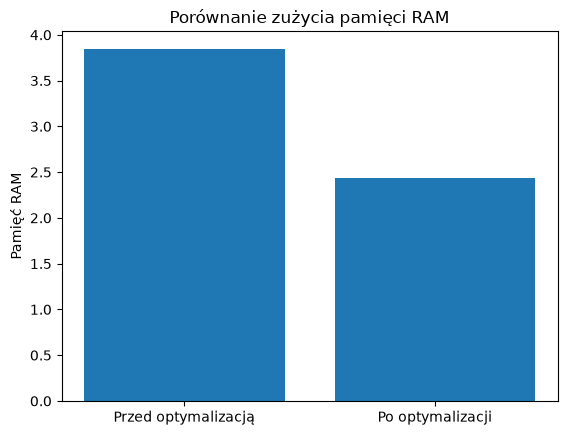

In [55]:
memory_values = [memory_original / 1024**3,memory_optimized / 1024**3]

plt.bar(["Przed optymalizacją", "Po optymalizacji"],memory_values)

plt.ylabel("Pamięć RAM")
plt.title("Porównanie zużycia pamięci RAM")
plt.show()

# Zadanie 3

## Pomiar czasu wykonywania operacji

### Operacja 1
Grupowanie

In [56]:
start = datetime.now()

result_original_1 = df_original.groupby("category")["likes"].mean()
time_original_1 = datetime.now() - start
print("Czas dla danych oryginalnych:", time_original_1)

Czas dla danych oryginalnych: 0:00:00.704689


In [57]:
start = datetime.now()

result_optimized_1 = df_optimized.groupby("category",observed=True)["likes"].mean()
time_optimized_1 = datetime.now() - start
print("Czas dla danych zoptymalizowanych:", time_optimized_1)

Czas dla danych zoptymalizowanych: 0:00:00.202122


### Operacja 2
Filtrowanie

In [58]:
start = datetime.now()
result_original_2 = df_original[df_original["likes"] > 1000]
time_original_2 = datetime.now() - start
print("Czas dla danych oryginalnych:", time_original_2)

Czas dla danych oryginalnych: 0:00:07.034945


In [59]:
start = datetime.now()
result_optimized_2 = df_optimized[df_optimized["likes"] > 1000]
time_optimized_2 = datetime.now() - start
print("Czas dla danych zoptymalizowanych:", time_optimized_2)

Czas dla danych zoptymalizowanych: 0:00:00.320116


### Operacja 3
Suma komentarzy

In [60]:
start = datetime.now()
result_original_3 = df_original.groupby( "post_type")["comments"].sum()
time_original_3 = datetime.now() - start
print("Czas dla danych oryginalnych:", time_original_3)

Czas dla danych oryginalnych: 0:00:00.173881


In [61]:
start = datetime.now()
result_optimized_3 = df_optimized.groupby("post_type")["comments"].sum()
time_optimized_3 = datetime.now() - start
print("Czas dla danych zoptymalizowanych:", time_optimized_3)

Czas dla danych zoptymalizowanych: 0:00:00.132582


## Zadanie 4

### Zapis danych do pliku csv

In [62]:
df_original.to_csv("plik.csv",header=True,index=False)

In [63]:
sizeof_fmt(os.path.getsize("plik.csv"))

'3.3GiB'

### Różnice między formatem csv a parquet

In [64]:
parquet_size = sum(os.path.getsize(file) for file in files)
csv_size = os.path.getsize("plik.csv")

print("Parquet:", sizeof_fmt(parquet_size))
print("CSV:", sizeof_fmt(csv_size))

Parquet: 1.3GiB
CSV: 3.3GiB


## Zadanie 5

### Wczytanie pliku

In [65]:
start = datetime.now()
df_csv = pd.read_csv("plik.csv")
time_normal = datetime.now() - start
print("Czas zwykłego wczytania:", time_normal)

Czas zwykłego wczytania: 0:01:13.138437


### Wczytanie pliku z użyciem chunksize

In [66]:
start = datetime.now()
chunks = pd.read_csv("plik.csv",chunksize=500_000)
df_csv_chunks = pd.concat(chunks,ignore_index=True)
time_chunks = datetime.now() - start
print("Czas wczytania z chunksize:", time_chunks)

Czas wczytania z chunksize: 0:00:53.034260


### Wczytanie wieloprocesowe

In [67]:
cores = os.cpu_count()
print("Liczba logicznych rdzeni:", cores)

Liczba logicznych rdzeni: 16


In [68]:
processes_1 = max(1, cores - 2)
processes_2 = max(1, (cores - 2) * 2)
print("Liczba procesów - wariant 1:", processes_1)
print("Liczba procesów - wariant 2:", processes_2)

Liczba procesów - wariant 1: 14
Liczba procesów - wariant 2: 28


In [69]:
from filesplit.split import Split
split = Split("plik.csv", "csv_parts")
split.bylinecount(linecount=1_000_000,includeheader=True)

Liczba plików: 10\
Liczba procesów: 14\
Czas: 0:00:17.665930\
Czas końcowy: 0:00:17.665930

Liczba plików: 10\
Liczba procesów: 28\
Czas: 0:00:19.158541\
Czas końcowy: 0:00:19.158541